✅ 4147 registros carregados do CSV
Processando 20 documentos...
  [1/20] 3038_647aaaf80bb5c51ca930c209bcf829e7.jpeg... ✓
  [2/20] 3108_59162b3602a856cc3c8c3200e1e78c5e.jpeg... ✓
  [3/20] 446_0698a693a3d0d0f970da2e9e96418b80.jpeg... ✓
  [4/20] 1729_5b8bb4fb9fef11731803b7aebbf05685.jpeg... ✓
  [5/20] 1687_ef0d6c1966f5cfa21543a28f5aef5969.jpeg... ✓
  [6/20] 4451_54a645527caf214725305231be135644.jpeg... ✓
  [7/20] 2250_0831abb78e025432c78d806e97cd9e80.jpeg... ✓
  [8/20] 435_f1c7b276c2e86ce5722cbe0d5b19a854.jpeg... ✓
  [9/20] 5112_efa197ea41041c7506aa68c5534fc0f6.jpeg... ✓
  [10/20] 5433_cd338ca307663fae61cc6d9330c01e2e.jpeg... ✓
  [11/20] 090_273ae80ff534c83cf0c592d764ee3e3f.jpeg... ✓
  [12/20] 1909_244dc767cbab2c8707dfa75cb282f0be.jpeg... ✓
  [13/20] 610_b31f2e7d898f66dfa0a51455b81a43fe.jpeg... ✓
  [14/20] 1926_3820a650f74087e61b0596721d603d64.jpeg... ✓
  [15/20] 1499_b1a7b1271afe496bb9048037d71574b9.jpeg... ✓
  [16/20] 437_a5904948a62285c65fd1c0b0841a7e69.jpeg... ✓
  [17/20] 2772_20d7820

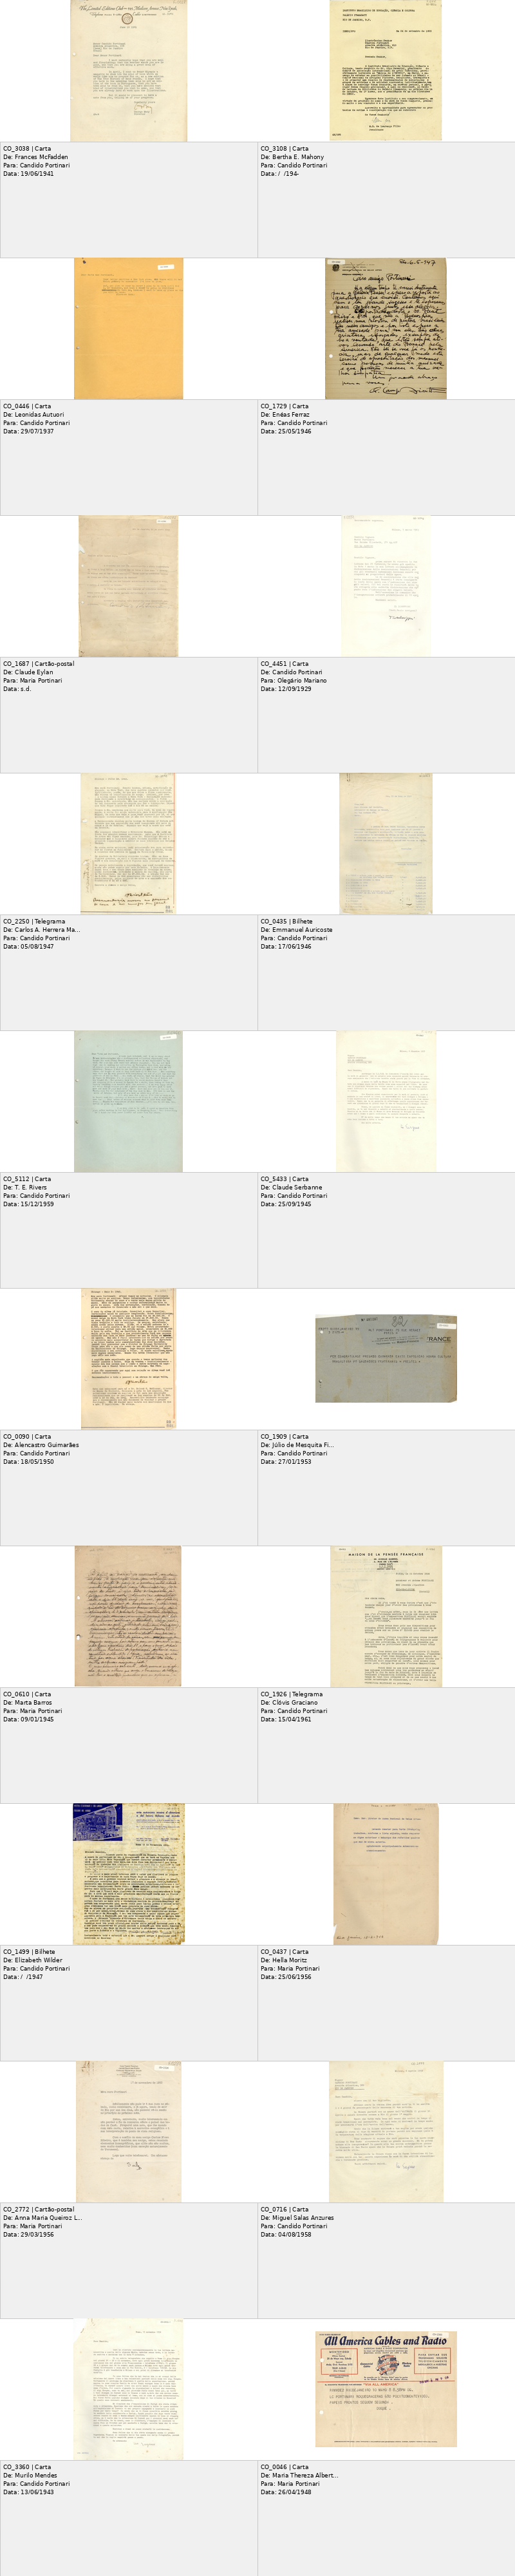

In [2]:
# Pequeno código para pegar as cartas de ../Data/Documentos_digitados/digitado e comparar 
# com os dados de ../Data/dados_correspondencias.csv, para fazer uma pequena análise.

import os
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import random

def criar_galeria_correspondencias(num_documentos=20, tamanho_celula=400, output_path="galeria_correspondencias.png"):
    """
    Cria uma galeria visual com cartas digitalizadas e seus dados do CSV.

    Args:
        num_documentos: Quantidade de documentos a exibir
        tamanho_celula: Tamanho de cada célula em pixels
        output_path: Caminho para salvar a imagem final
    """

    # Caminhos
    pasta_docs = "../Data/Documentos_digitados/digitado"
    csv_dados = "../Data/dados_correspondencias.csv"

    # Verifica se existem
    if not os.path.exists(pasta_docs):
        print(f"Erro: Pasta {pasta_docs} não encontrada!")
        return

    if not os.path.exists(csv_dados):
        print(f"Erro: Arquivo {csv_dados} não encontrado!")
        return

    # Carrega CSV
    df = pd.read_csv(csv_dados)
    print(f"✅ {len(df)} registros carregados do CSV")

    # Lista imagens
    imagens = [f for f in os.listdir(pasta_docs) 
               if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not imagens:
        print(f"Erro: Nenhuma imagem encontrada em {pasta_docs}")
        return

    # Seleciona aleatoriamente
    imagens_selecionadas = random.sample(imagens, min(num_documentos, len(imagens)))
    print(f"Processando {len(imagens_selecionadas)} documentos...")

    # Configurar grid
    colunas = 2
    linhas = (len(imagens_selecionadas) + colunas - 1) // colunas
    altura_dados = 180
    tamanho_img = tamanho_celula - altura_dados

    # Dimensões finais
    largura_final = colunas * tamanho_celula
    altura_final = linhas * tamanho_celula

    # Criar imagem branca
    grid_image = Image.new('RGB', (largura_final, altura_final), color='white')
    draw = ImageDraw.Draw(grid_image)

    # Carregar fontes
    try:
        fonte_titulo = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 10)
        fonte_texto = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
    except:
        fonte_titulo = ImageFont.load_default()
        fonte_texto = ImageFont.load_default()

    # Processar cada documento
    for idx, nome_img in enumerate(imagens_selecionadas):
        caminho_img = os.path.join(pasta_docs, nome_img)

        # Calcular posição
        linha = idx // colunas
        coluna = idx % colunas
        x_inicio = coluna * tamanho_celula
        y_inicio = linha * tamanho_celula

        try:
            # Extrair ID do documento do nome do arquivo (CO_XXXX do início do nome)
            partes = nome_img.split('_')
            if len(partes[0]) <= 3:
                id_doc = 'CO_0' + partes[0]  # Ex: CO_0001
            else:
                id_doc = 'CO_' + partes[0]  # Ex: CO_4390

            # Buscar dados no CSV
            dados_doc = df[df['id_doc'] == id_doc]

            # Carregar e redimensionar imagem
            img = Image.open(caminho_img).convert('RGB')
            img.thumbnail((tamanho_img, tamanho_img), Image.Resampling.LANCZOS)

            # Centralizar imagem
            x_pos = x_inicio + (tamanho_celula - img.width) // 2
            y_pos = y_inicio + (tamanho_img - img.height) // 2

            grid_image.paste(img, (x_pos, y_pos))

            print(f"  [{idx+1}/{len(imagens_selecionadas)}] {nome_img}...", end="")

            # Desenhar fundo para dados
            y_dados = y_inicio + tamanho_img
            draw.rectangle([x_inicio, y_dados, x_inicio + tamanho_celula, 
                          y_inicio + tamanho_celula], fill=(240, 240, 240), outline=(200, 200, 200))

            # Formatar dados
            if not dados_doc.empty:
                row = dados_doc.iloc[0]
                remetente = str(row['remetente'])[:20] + "..." if len(str(row['remetente'])) > 20 else str(row['remetente'])
                destinatario = str(row['destinatario'])[:20] + "..." if len(str(row['destinatario'])) > 20 else str(row['destinatario'])
                data = str(row['data']) if pd.notna(row['data']) else "s.d."
                tipo = str(row['tipo_doc'])

                texto = f"{id_doc} | {tipo}\n"
                texto += f"De: {remetente}\n"
                texto += f"Para: {destinatario}\n"
                texto += f"Data: {data}"

                draw.text((x_inicio + 5, y_dados + 5), texto, fill='black', font=fonte_texto)
                print(" ✓")
            else:
                draw.text((x_inicio + 5, y_dados + 5), f"{id_doc}\n(sem dados)", fill='gray', font=fonte_texto)
                print(" ⚠ (sem dados)")

        except Exception as e:
            print(f" ✗ {e}")
            draw.text((x_inicio + 10, y_inicio + 10), "Erro", fill='red', font=fonte_texto)

    # Salvar
    '''grid_image.save(output_path)
    print(f"\n✓ Galeria salva em: {output_path}")
    print(f"  Dimensões: {largura_final}x{altura_final} pixels")'''
    return grid_image

# Rodar
criar_galeria_correspondencias(num_documentos=20, tamanho_celula=400, 
                               output_path="galeria_correspondencias.png")